# Uranium-235 (U235) Analysis
## NDA + Machine Learning — Replaced Pin Detection
**Fatima Ballout | Master's Thesis, University of Padova 2023–2024**

---
This notebook trains and evaluates 4 classifiers and 4 regressors on the **Uranium-235 (U235)** isotope scenario.
- **Classification**: Binary — intact (0) vs modified assembly (1)
- **Regression**: Predict number of replaced pins (0–130)

## 1. Imports

In [1]:
import os
import copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    mean_absolute_error, mean_squared_error, r2_score
)
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 123
TEST_SIZE    = 0.2
N_FOLDS      = 5
DATA_DIR     = '/Users/fatimaballout/desktop/Thesis Work 2'

print('Imports OK')

Imports OK


## 2. Load Data

In [2]:
# Classification dataset
clf_path = os.path.join(DATA_DIR, 'U235_filtered_dataframe_with_file.parquet')
df_clf = pd.read_parquet(clf_path)
print('Classification dataset:', df_clf.shape)
print('MODab_Flag distribution:')
print(df_clf['MODab_Flag'].value_counts().to_frame('Count'))

# Regression dataset  
reg_path = os.path.join(DATA_DIR, 'filtered_dataframe_No_U235.parquet')
df_reg = pd.read_parquet(reg_path)
print('\nRegression dataset:', df_reg.shape)
print('Total Replaced Pins:')
print(df_reg['Total Replaced Pins'].describe().round(2))

Classification dataset: (14898, 67)
MODab_Flag distribution:
   Count
1  12154
0   2744

Regression dataset: (14898, 67)
Total Replaced Pins:
count    14898.00
mean        53.48
std         48.89
min          0.00
25%          7.00
50%         38.00
75%        114.00
max        130.00
Name: Total Replaced Pins, dtype: float64


## 3. Data Overview

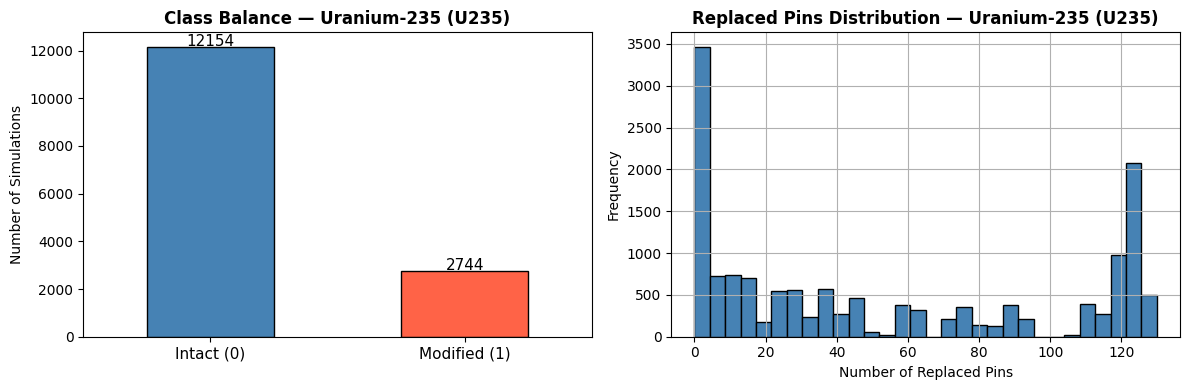

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_clf['MODab_Flag'].value_counts().plot.bar(
    ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
axes[0].set_xticklabels(['Intact (0)', 'Modified (1)'], rotation=0, fontsize=11)
axes[0].set_title('Class Balance — Uranium-235 (U235)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Simulations')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{int(bar.get_height())}', ha='center', fontsize=11)

df_reg['Total Replaced Pins'].hist(ax=axes[1], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Replaced Pins Distribution — Uranium-235 (U235)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Replaced Pins')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('Uranium-235_(U235)_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Helper Functions

In [4]:
def prepare_clf(df):
    cols_drop = ['MODab_Flag']
    for c in df.columns:
        if df[c].dtype == object:
            cols_drop.append(c)
    X = df.drop(columns=list(set(cols_drop)), errors='ignore')
    y = df['MODab_Flag']
    return X, y


def prepare_reg(df):
    cols_drop = ['Total Replaced Pins', 'MODab_Flag']
    for c in df.columns:
        if df[c].dtype == object:
            cols_drop.append(c)
    X = df.drop(columns=list(set(cols_drop)), errors='ignore')
    y = df['Total Replaced Pins']
    return X, y


def cv_classification(model, X, y, n=N_FOLDS):
    skf = StratifiedKFold(n_splits=n, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(model, X, y, cv=skf,
        scoring=['accuracy','precision_weighted','recall_weighted','f1_weighted','roc_auc'])
    return pd.DataFrame({
        'Fold':      range(1, n+1),
        'Accuracy':  scores['test_accuracy'].round(4),
        'Precision': scores['test_precision_weighted'].round(4),
        'Recall':    scores['test_recall_weighted'].round(4),
        'F1':        scores['test_f1_weighted'].round(4),
        'AUC':       scores['test_roc_auc'].round(4),
    })


def cv_regression(model, X, y, n=N_FOLDS):
    kf = KFold(n_splits=n, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(model, X, y, cv=kf,
        scoring=['neg_mean_absolute_error','neg_root_mean_squared_error','r2'])
    return pd.DataFrame({
        'Fold': range(1, n+1),
        'MAE':  (-scores['test_neg_mean_absolute_error']).round(4),
        'RMSE': (-scores['test_neg_root_mean_squared_error']).round(4),
        'R2':   scores['test_r2'].round(4),
    })


def eval_classifier(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    auc  = roc_auc_score(y_te, y_proba)

    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1:        {f1:.4f}')
    print(f'  AUC-ROC:   {auc:.4f}')
    print()
    print(classification_report(y_te, y_pred, zero_division=0))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Intact','Modified'], yticklabels=['Intact','Modified'])
    axes[0].set_title(f'Confusion Matrix — {name}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_te, y_proba)
    axes[1].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc:.4f}')
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
    axes[1].plot([0,1],[0,1],'k--',lw=1)
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve — {name}', fontsize=12, fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=11)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}_clf.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'Model': name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1': round(f1,4), 'AUC': round(auc,4)}


def eval_regressor(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)

    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  MAE:  {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  R²:   {r2:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].scatter(y_te, y_pred, alpha=0.3, s=8, color='steelblue')
    mn = min(y_te.min(), y_pred.min()); mx = max(y_te.max(), y_pred.max())
    axes[0].plot([mn,mx],[mn,mx],'r--',lw=1.5,label='Perfect fit')
    axes[0].set_xlabel('Actual Replaced Pins'); axes[0].set_ylabel('Predicted Replaced Pins')
    axes[0].set_title(f'Prediction Error — {name}', fontsize=12, fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].text(0.05, 0.92, f'R² = {r2:.4f}\nRMSE = {rmse:.4f}',
                 transform=axes[0].transAxes, fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    residuals = y_te - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.3, s=8, color='tomato')
    axes[1].axhline(0, color='black', lw=1.5, ls='--')
    axes[1].set_xlabel('Predicted Replaced Pins'); axes[1].set_ylabel('Residuals')
    axes[1].set_title(f'Residuals Plot — {name}', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}_reg.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'Model': name, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R2': round(r2,4)}

print('Helper functions defined.')

Helper functions defined.


## 5. Define Models

In [5]:
classifiers = {
    'Extra Trees Classifier': ExtraTreesClassifier(
        n_estimators=100, criterion='gini', max_depth=None,
        max_features='sqrt', min_samples_leaf=1, min_samples_split=2,
        bootstrap=False, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest Classifier': RandomForestClassifier(
        n_estimators=100, criterion='gini', max_depth=None,
        max_features='sqrt', min_samples_leaf=1, min_samples_split=2,
        bootstrap=True, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'KNN Classifier': KNeighborsClassifier(
        n_neighbors=5, weights='uniform', metric='minkowski'
    ),
    'LGBM Classifier': lgb.LGBMClassifier(
        n_estimators=100, learning_rate=0.1, num_leaves=31,
        class_weight='balanced', random_state=RANDOM_STATE, verbose=-1
    ),
}

regressors = {
    'Extra Trees Regressor': ExtraTreesRegressor(
        n_estimators=100, max_depth=None, max_features='sqrt',
        min_samples_leaf=1, min_samples_split=2,
        bootstrap=False, random_state=RANDOM_STATE
    ),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=100, max_depth=None, max_features='sqrt',
        min_samples_leaf=1, min_samples_split=2,
        bootstrap=True, random_state=RANDOM_STATE
    ),
    'KNN Regressor': KNeighborsRegressor(
        n_neighbors=5, weights='uniform', metric='minkowski'
    ),
    'LGBM Regressor': lgb.LGBMRegressor(
        n_estimators=100, learning_rate=0.1, num_leaves=31,
        random_state=RANDOM_STATE, verbose=-1
    ),
}
print('Models defined.')

Models defined.


## 6. Prepare Train / Test Sets

In [6]:
# Classification
X_clf, y_clf = prepare_clf(df_clf)
scaler_clf   = StandardScaler()
X_clf_sc     = scaler_clf.fit_transform(X_clf)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clf_sc, y_clf, test_size=TEST_SIZE, random_state=42, stratify=y_clf)

print(f'Classification — Train: {X_tr_c.shape}, Test: {X_te_c.shape}')
print(f'Features: {X_clf.shape[1]}')

# Regression
X_reg, y_reg = prepare_reg(df_reg)
scaler_reg   = StandardScaler()
X_reg_sc     = scaler_reg.fit_transform(X_reg)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg_sc, y_reg, test_size=TEST_SIZE, random_state=42)

print(f'\nRegression — Train: {X_tr_r.shape}, Test: {X_te_r.shape}')

Classification — Train: (11918, 65), Test: (2980, 65)
Features: 65

Regression — Train: (11918, 65), Test: (2980, 65)


## 7. Classification — Uranium-235 (U235)
**Task:** Predict whether the fuel assembly has replaced pins (0=intact, 1=modified)

### 7.1 Extra Trees Classifier

In [7]:
# Cross-Validation
print('--- Extra Trees Classifier | 5-Fold Cross-Validation ---')
cv_df = cv_classification(copy.deepcopy(classifiers['Extra Trees Classifier']), X_clf_sc, y_clf)
print(cv_df.to_string(index=False))
print(f'Mean Accuracy: {cv_df["Accuracy"].mean():.4f} ± {cv_df["Accuracy"].std():.4f}')
print(f'Mean AUC:      {cv_df["AUC"].mean():.4f} ± {cv_df["AUC"].std():.4f}')

--- Extra Trees Classifier | 5-Fold Cross-Validation ---
 Fold  Accuracy  Precision  Recall     F1    AUC
    1    0.9872     0.9873  0.9872 0.9871 0.9964
    2    0.9906     0.9906  0.9906 0.9906 0.9975
    3    0.9876     0.9876  0.9876 0.9875 0.9989
    4    0.9916     0.9916  0.9916 0.9915 0.9991
    5    0.9872     0.9873  0.9872 0.9871 0.9972
Mean Accuracy: 0.9888 ± 0.0021
Mean AUC:      0.9978 ± 0.0012



  Extra Trees Classifier
  Accuracy:  0.9883
  Precision: 0.9883
  Recall:    0.9883
  F1:        0.9882
  AUC-ROC:   0.9982

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       549
           1       0.99      1.00      0.99      2431

    accuracy                           0.99      2980
   macro avg       0.99      0.97      0.98      2980
weighted avg       0.99      0.99      0.99      2980



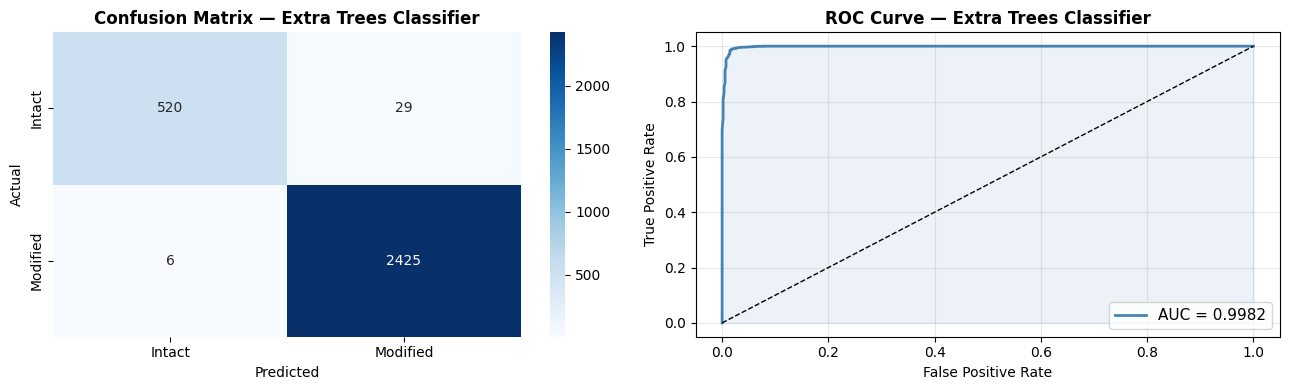

In [8]:
# Train & Evaluate
result_extra_trees_classifier = eval_classifier(
    copy.deepcopy(classifiers['Extra Trees Classifier']),
    X_tr_c, X_te_c, y_tr_c, y_te_c, 'Extra Trees Classifier'
)

### 7.2 Random Forest Classifier

In [9]:
# Cross-Validation
print('--- Random Forest Classifier | 5-Fold Cross-Validation ---')
cv_df = cv_classification(copy.deepcopy(classifiers['Random Forest Classifier']), X_clf_sc, y_clf)
print(cv_df.to_string(index=False))
print(f'Mean Accuracy: {cv_df["Accuracy"].mean():.4f} ± {cv_df["Accuracy"].std():.4f}')
print(f'Mean AUC:      {cv_df["AUC"].mean():.4f} ± {cv_df["AUC"].std():.4f}')

--- Random Forest Classifier | 5-Fold Cross-Validation ---
 Fold  Accuracy  Precision  Recall     F1    AUC
    1    0.9876     0.9876  0.9876 0.9875 0.9950
    2    0.9903     0.9903  0.9903 0.9902 0.9970
    3    0.9862     0.9863  0.9862 0.9861 0.9986
    4    0.9866     0.9866  0.9866 0.9864 0.9980
    5    0.9852     0.9852  0.9852 0.9851 0.9948
Mean Accuracy: 0.9872 ± 0.0019
Mean AUC:      0.9967 ± 0.0017



  Random Forest Classifier
  Accuracy:  0.9889
  Precision: 0.9889
  Recall:    0.9889
  F1:        0.9888
  AUC-ROC:   0.9982

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       549
           1       0.99      1.00      0.99      2431

    accuracy                           0.99      2980
   macro avg       0.99      0.97      0.98      2980
weighted avg       0.99      0.99      0.99      2980



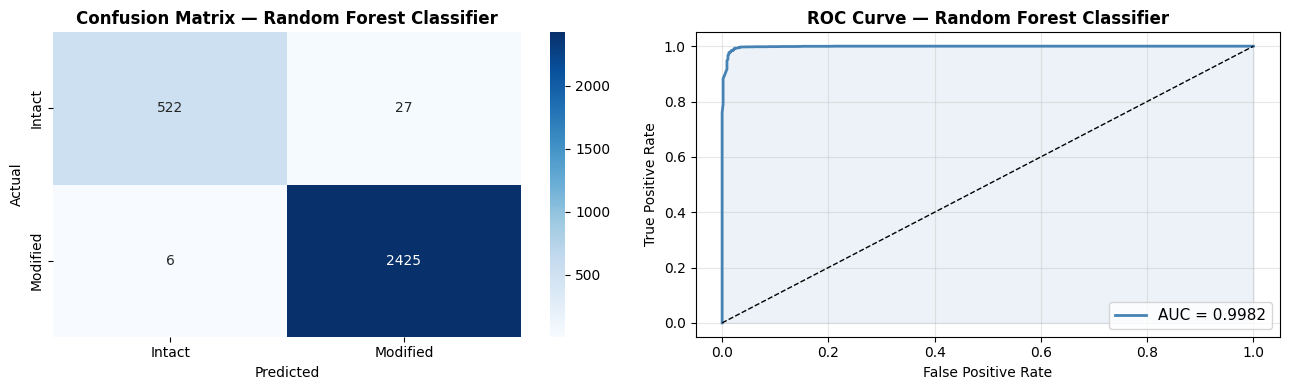

In [10]:
# Train & Evaluate
result_random_forest_classifier = eval_classifier(
    copy.deepcopy(classifiers['Random Forest Classifier']),
    X_tr_c, X_te_c, y_tr_c, y_te_c, 'Random Forest Classifier'
)

### 7.3 KNN Classifier

In [11]:
# Cross-Validation
print('--- KNN Classifier | 5-Fold Cross-Validation ---')
cv_df = cv_classification(copy.deepcopy(classifiers['KNN Classifier']), X_clf_sc, y_clf)
print(cv_df.to_string(index=False))
print(f'Mean Accuracy: {cv_df["Accuracy"].mean():.4f} ± {cv_df["Accuracy"].std():.4f}')
print(f'Mean AUC:      {cv_df["AUC"].mean():.4f} ± {cv_df["AUC"].std():.4f}')

--- KNN Classifier | 5-Fold Cross-Validation ---
 Fold  Accuracy  Precision  Recall     F1    AUC
    1    0.9537     0.9580  0.9537 0.9549 0.9865
    2    0.9597     0.9638  0.9597 0.9608 0.9906
    3    0.9570     0.9601  0.9570 0.9579 0.9886
    4    0.9621     0.9654  0.9621 0.9629 0.9917
    5    0.9631     0.9668  0.9631 0.9640 0.9907
Mean Accuracy: 0.9591 ± 0.0038
Mean AUC:      0.9896 ± 0.0021



  KNN Classifier
  Accuracy:  0.9611
  Precision: 0.9645
  Recall:    0.9611
  F1:        0.9620
  AUC-ROC:   0.9887

              precision    recall  f1-score   support

           0       0.85      0.96      0.90       549
           1       0.99      0.96      0.98      2431

    accuracy                           0.96      2980
   macro avg       0.92      0.96      0.94      2980
weighted avg       0.96      0.96      0.96      2980



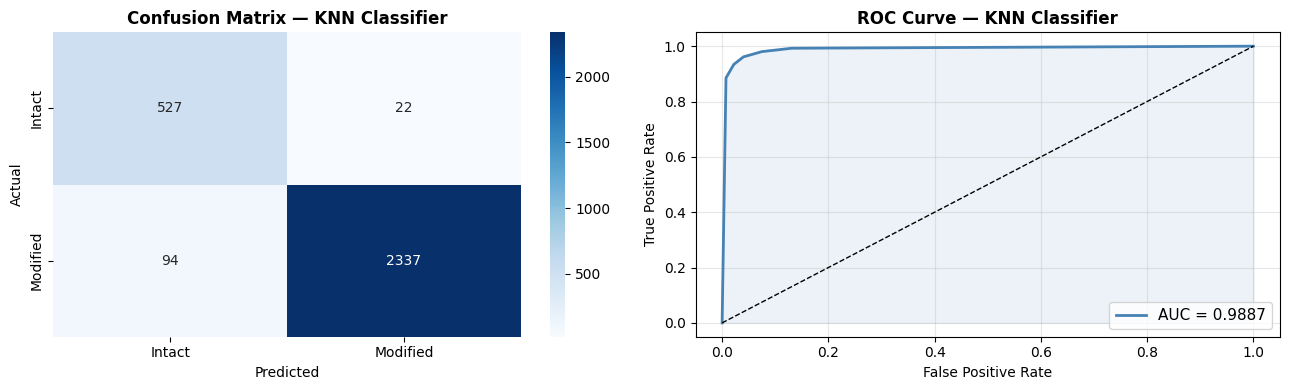

In [12]:
# Train & Evaluate
result_knn_classifier = eval_classifier(
    copy.deepcopy(classifiers['KNN Classifier']),
    X_tr_c, X_te_c, y_tr_c, y_te_c, 'KNN Classifier'
)

### 7.4 LGBM Classifier

In [13]:
# Cross-Validation
print('--- LGBM Classifier | 5-Fold Cross-Validation ---')
cv_df = cv_classification(copy.deepcopy(classifiers['LGBM Classifier']), X_clf_sc, y_clf)
print(cv_df.to_string(index=False))
print(f'Mean Accuracy: {cv_df["Accuracy"].mean():.4f} ± {cv_df["Accuracy"].std():.4f}')
print(f'Mean AUC:      {cv_df["AUC"].mean():.4f} ± {cv_df["AUC"].std():.4f}')

--- LGBM Classifier | 5-Fold Cross-Validation ---
 Fold  Accuracy  Precision  Recall     F1    AUC
    1    0.9711     0.9725  0.9711 0.9715 0.9956
    2    0.9725     0.9745  0.9725 0.9730 0.9963
    3    0.9748     0.9762  0.9748 0.9752 0.9972
    4    0.9752     0.9765  0.9752 0.9755 0.9977
    5    0.9728     0.9742  0.9728 0.9732 0.9962
Mean Accuracy: 0.9733 ± 0.0017
Mean AUC:      0.9966 ± 0.0008



  LGBM Classifier
  Accuracy:  0.9728
  Precision: 0.9751
  Recall:    0.9728
  F1:        0.9734
  AUC-ROC:   0.9972

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       549
           1       1.00      0.97      0.98      2431

    accuracy                           0.97      2980
   macro avg       0.94      0.98      0.96      2980
weighted avg       0.98      0.97      0.97      2980



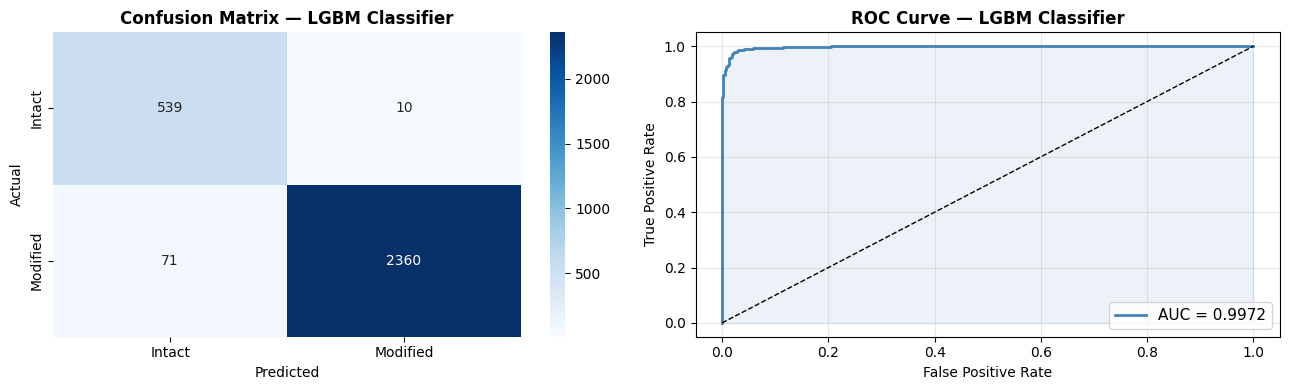

In [14]:
# Train & Evaluate
result_lgbm_classifier = eval_classifier(
    copy.deepcopy(classifiers['LGBM Classifier']),
    X_tr_c, X_te_c, y_tr_c, y_te_c, 'LGBM Classifier'
)

### 7.5 Classification Summary

                   Model  Accuracy  Precision  Recall     F1    AUC
  Extra Trees Classifier    0.9883     0.9883  0.9883 0.9882 0.9982
Random Forest Classifier    0.9889     0.9889  0.9889 0.9888 0.9982
          KNN Classifier    0.9611     0.9645  0.9611 0.9620 0.9887
         LGBM Classifier    0.9728     0.9751  0.9728 0.9734 0.9972


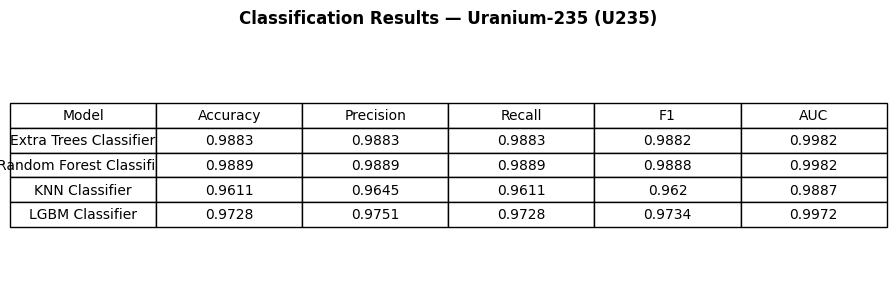

In [15]:
clf_summary = pd.DataFrame([
    result_extra_trees_classifier,
    result_random_forest_classifier,
    result_knn_classifier,
    result_lgbm_classifier,
])
print(clf_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3))
ax.axis('off')
tbl = ax.table(cellText=clf_summary.values, colLabels=clf_summary.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.5)
plt.title(f'Classification Results — Uranium-235 (U235)', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('classification_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Regression — Uranium-235 (U235)
**Task:** Predict the exact number of replaced pins (0–130)

### 8.1 Extra Trees Regressor

In [16]:
# Cross-Validation
print('--- Extra Trees Regressor | 5-Fold Cross-Validation ---')
cv_df = cv_regression(copy.deepcopy(regressors['Extra Trees Regressor']), X_reg_sc, y_reg)
print(cv_df.to_string(index=False))
print(f'Mean MAE:  {cv_df["MAE"].mean():.4f} ± {cv_df["MAE"].std():.4f}')
print(f'Mean RMSE: {cv_df["RMSE"].mean():.4f} ± {cv_df["RMSE"].std():.4f}')
print(f'Mean R²:   {cv_df["R2"].mean():.4f} ± {cv_df["R2"].std():.4f}')

--- Extra Trees Regressor | 5-Fold Cross-Validation ---
 Fold    MAE   RMSE     R2
    1 4.3317 8.6672 0.9684
    2 4.1382 8.4236 0.9702
    3 4.3335 9.0196 0.9667
    4 4.6521 9.3644 0.9637
    5 4.1916 8.5471 0.9688
Mean MAE:  4.3294 ± 0.1998
Mean RMSE: 8.8044 ± 0.3840
Mean R²:   0.9676 ± 0.0025



  Extra Trees Regressor
  MAE:  4.3750
  RMSE: 9.5415
  R²:   0.9626


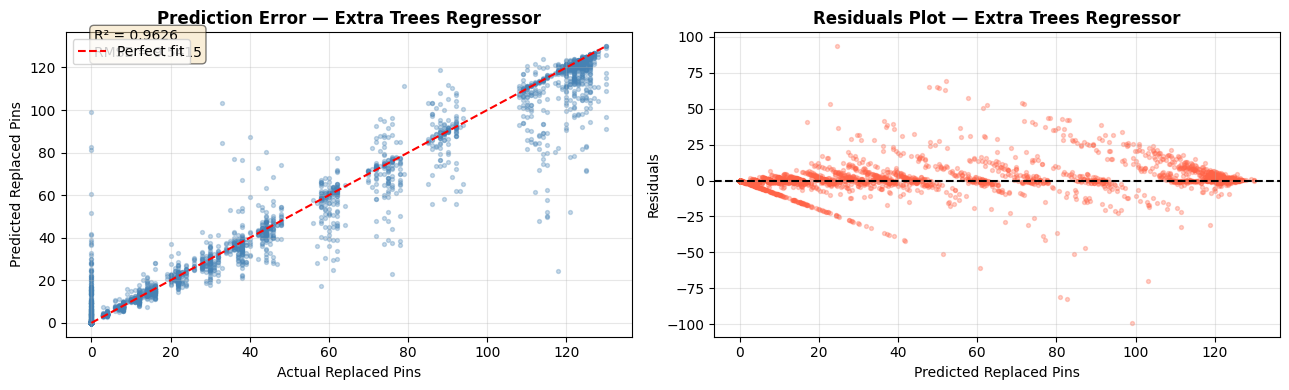

In [17]:
# Train & Evaluate
result_extra_trees_regressor = eval_regressor(
    copy.deepcopy(regressors['Extra Trees Regressor']),
    X_tr_r, X_te_r, y_tr_r, y_te_r, 'Extra Trees Regressor'
)

### 8.2 Random Forest Regressor

In [18]:
# Cross-Validation
print('--- Random Forest Regressor | 5-Fold Cross-Validation ---')
cv_df = cv_regression(copy.deepcopy(regressors['Random Forest Regressor']), X_reg_sc, y_reg)
print(cv_df.to_string(index=False))
print(f'Mean MAE:  {cv_df["MAE"].mean():.4f} ± {cv_df["MAE"].std():.4f}')
print(f'Mean RMSE: {cv_df["RMSE"].mean():.4f} ± {cv_df["RMSE"].std():.4f}')
print(f'Mean R²:   {cv_df["R2"].mean():.4f} ± {cv_df["R2"].std():.4f}')

--- Random Forest Regressor | 5-Fold Cross-Validation ---
 Fold    MAE    RMSE     R2
    1 5.0504  9.6490 0.9608
    2 4.8422  9.3415 0.9633
    3 5.1526 10.2611 0.9568
    4 5.2356  9.9723 0.9588
    5 4.8945  9.5054 0.9614
Mean MAE:  5.0351 ± 0.1667
Mean RMSE: 9.7459 ± 0.3700
Mean R²:   0.9602 ± 0.0025



  Random Forest Regressor
  MAE:  5.0574
  RMSE: 10.3539
  R²:   0.9560


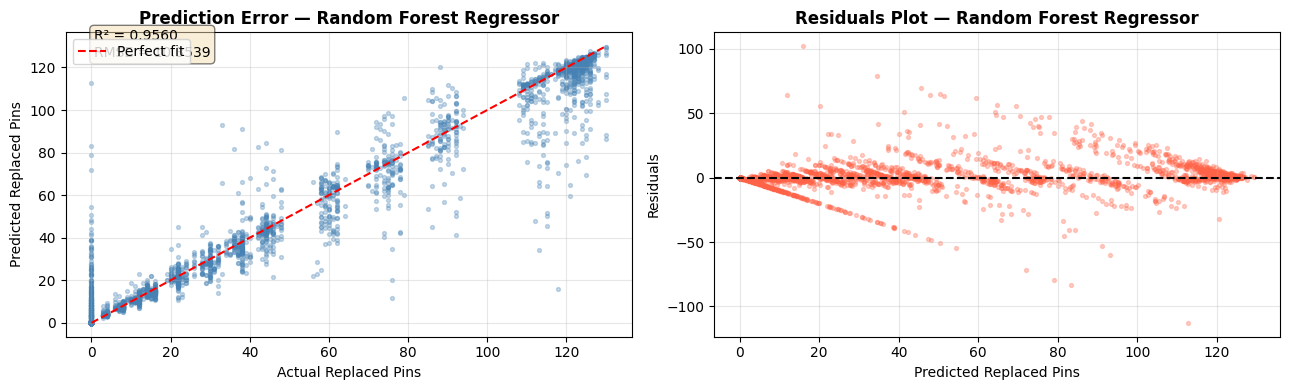

In [19]:
# Train & Evaluate
result_random_forest_regressor = eval_regressor(
    copy.deepcopy(regressors['Random Forest Regressor']),
    X_tr_r, X_te_r, y_tr_r, y_te_r, 'Random Forest Regressor'
)

### 8.3 KNN Regressor

In [20]:
# Cross-Validation
print('--- KNN Regressor | 5-Fold Cross-Validation ---')
cv_df = cv_regression(copy.deepcopy(regressors['KNN Regressor']), X_reg_sc, y_reg)
print(cv_df.to_string(index=False))
print(f'Mean MAE:  {cv_df["MAE"].mean():.4f} ± {cv_df["MAE"].std():.4f}')
print(f'Mean RMSE: {cv_df["RMSE"].mean():.4f} ± {cv_df["RMSE"].std():.4f}')
print(f'Mean R²:   {cv_df["R2"].mean():.4f} ± {cv_df["R2"].std():.4f}')

--- KNN Regressor | 5-Fold Cross-Validation ---
 Fold    MAE    RMSE     R2
    1 5.4450 13.1478 0.9273
    2 5.6123 14.2941 0.9141
    3 5.6140 13.8907 0.9209
    4 6.0518 15.3236 0.9027
    5 5.4279 13.1618 0.9260
Mean MAE:  5.6302 ± 0.2518
Mean RMSE: 13.9636 ± 0.9045
Mean R²:   0.9182 ± 0.0101



  KNN Regressor
  MAE:  5.5500
  RMSE: 13.5276
  R²:   0.9249


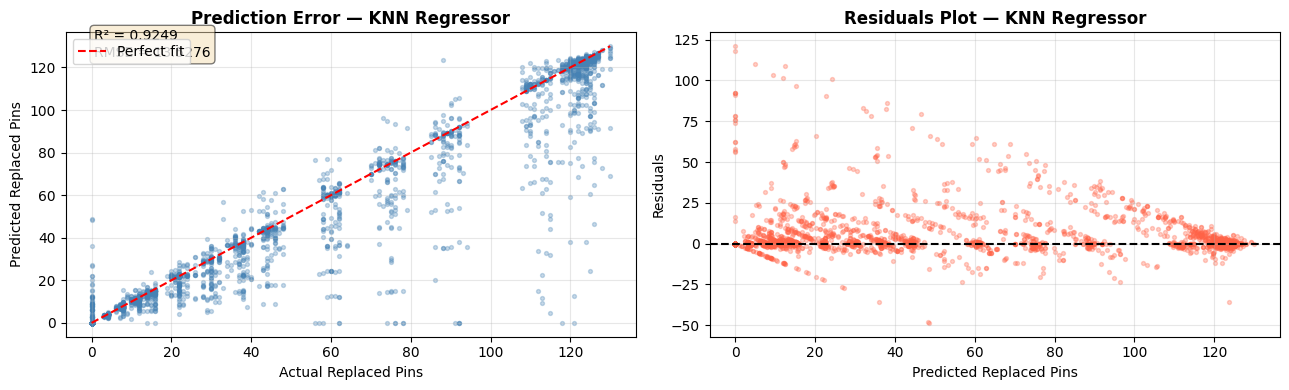

In [21]:
# Train & Evaluate
result_knn_regressor = eval_regressor(
    copy.deepcopy(regressors['KNN Regressor']),
    X_tr_r, X_te_r, y_tr_r, y_te_r, 'KNN Regressor'
)

### 8.4 LGBM Regressor

In [22]:
# Cross-Validation
print('--- LGBM Regressor | 5-Fold Cross-Validation ---')
cv_df = cv_regression(copy.deepcopy(regressors['LGBM Regressor']), X_reg_sc, y_reg)
print(cv_df.to_string(index=False))
print(f'Mean MAE:  {cv_df["MAE"].mean():.4f} ± {cv_df["MAE"].std():.4f}')
print(f'Mean RMSE: {cv_df["RMSE"].mean():.4f} ± {cv_df["RMSE"].std():.4f}')
print(f'Mean R²:   {cv_df["R2"].mean():.4f} ± {cv_df["R2"].std():.4f}')

--- LGBM Regressor | 5-Fold Cross-Validation ---
 Fold    MAE    RMSE     R2
    1 6.5476 10.6918 0.9519
    2 6.3222 10.5918 0.9528
    3 6.5862 10.7843 0.9523
    4 6.6470 10.7574 0.9521
    5 6.4824 10.5607 0.9523
Mean MAE:  6.5171 ± 0.1243
Mean RMSE: 10.6772 ± 0.0987
Mean R²:   0.9523 ± 0.0003



  LGBM Regressor
  MAE:  6.4685
  RMSE: 11.0471
  R²:   0.9499


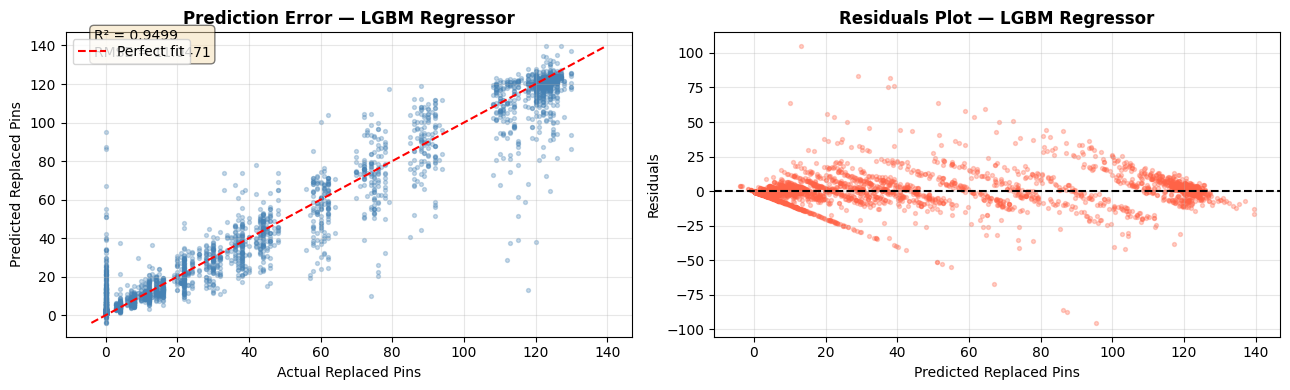

In [23]:
# Train & Evaluate
result_lgbm_regressor = eval_regressor(
    copy.deepcopy(regressors['LGBM Regressor']),
    X_tr_r, X_te_r, y_tr_r, y_te_r, 'LGBM Regressor'
)

### 8.5 Regression Summary

                  Model    MAE    RMSE     R2
  Extra Trees Regressor 4.3750  9.5415 0.9626
Random Forest Regressor 5.0574 10.3539 0.9560
          KNN Regressor 5.5500 13.5276 0.9249
         LGBM Regressor 6.4685 11.0471 0.9499


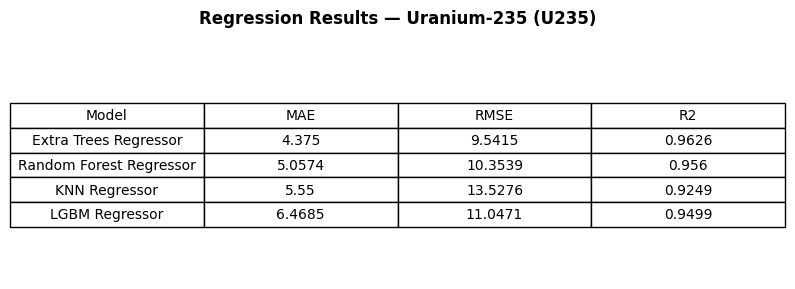

In [24]:
reg_summary = pd.DataFrame([
    result_extra_trees_regressor,
    result_random_forest_regressor,
    result_knn_regressor,
    result_lgbm_regressor,
])
print(reg_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
tbl = ax.table(cellText=reg_summary.values, colLabels=reg_summary.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.5)
plt.title(f'Regression Results — Uranium-235 (U235)', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('regression_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Export Results

In [25]:
with pd.ExcelWriter('Uranium-235_(U235)_results.xlsx') as writer:
    clf_summary.to_excel(writer, sheet_name='Classification', index=False)
    reg_summary.to_excel(writer, sheet_name='Regression', index=False)

print('Results saved to Uranium-235_(U235)_results.xlsx')

Results saved to Uranium-235_(U235)_results.xlsx
